In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, accuracy_score

In [2]:
cnn_only_predictions = pd.read_csv(
    "cnn_only_regex_predictions.csv"
)

cnn_motif_predictions = pd.read_csv(
    "cnn_plus_motif_predictions.csv"
)

lineage_order = sorted(
    set(cnn_only_predictions["true_lineage"])
    | set(cnn_only_predictions["predicted_lineage"])
    | set(cnn_motif_predictions["true_lineage"])
    | set(cnn_motif_predictions["predicted_lineage"])
)

lineage_order

['Duplornaviricota',
 'Kitrinoviricota',
 'Lenarviricota',
 'Negarnaviricota',
 'Pisuviricota']

In [17]:
def calculate_per_lineage_metrics(
    predictions_df,
    model_name,
    lineage_order
):
    rows = []

    for seed, seed_df in predictions_df.groupby("seed"):

        report = classification_report(
            seed_df["true_lineage"],
            seed_df["predicted_lineage"],
            labels=lineage_order,
            output_dict=True,
            zero_division=0
        )

        for lineage in lineage_order:
            rows.append({
                "model": model_name,
                "seed": seed,
                "lineage": lineage,
                "precision": report[lineage]["precision"],
                "recall": report[lineage]["recall"],
                "f1-score": report[lineage]["f1-score"]
            })

    return pd.DataFrame(rows)

In [4]:
def create_lineage_counts(
    predictions_df,
    model_name,
    lineage_order
):
    rows = []

    for seed, seed_df in predictions_df.groupby("seed"):

        true_counts = (
            seed_df["true_lineage"]
            .value_counts()
            .reindex(
                lineage_order,
                fill_value=0
            )
        )

        predicted_counts = (
            seed_df["predicted_lineage"]
            .value_counts()
            .reindex(
                lineage_order,
                fill_value=0
            )
        )

        for lineage in lineage_order:
            rows.append({
                "model": model_name,
                "seed": seed,
                "lineage": lineage,
                "type": "True",
                "count": true_counts[lineage]
            })

            rows.append({
                "model": model_name,
                "seed": seed,
                "lineage": lineage,
                "type": "Predicted",
                "count": predicted_counts[lineage]
            })

    return pd.DataFrame(rows)

In [13]:
def calculate_accuracy_by_seed(
    predictions_df,
    model_name
):
    rows = []

    for seed, seed_df in predictions_df.groupby("seed"):
        accuracy = accuracy_score(
            seed_df["true_lineage"],
            seed_df["predicted_lineage"]
        )

        rows.append({
            "model": model_name,
            "seed": seed,
            "accuracy": accuracy
        })

    return pd.DataFrame(rows)

In [18]:
cnn_only_lineage_metrics = calculate_per_lineage_metrics(
    predictions_df=cnn_only_predictions,
    model_name="CNN-only",
    lineage_order=lineage_order
)

cnn_motif_lineage_metrics = calculate_per_lineage_metrics(
    predictions_df=cnn_motif_predictions,
    model_name="CNN + motif",
    lineage_order=lineage_order
)

In [19]:
cnn_only_long = cnn_only_lineage_metrics.melt(
    id_vars=["model", "seed", "lineage"],
    value_vars=["precision", "recall", "f1-score"],
    var_name="metric",
    value_name="score"
)

cnn_motif_long = cnn_motif_lineage_metrics.melt(
    id_vars=["model", "seed", "lineage"],
    value_vars=["precision", "recall", "f1-score"],
    var_name="metric",
    value_name="score"
)

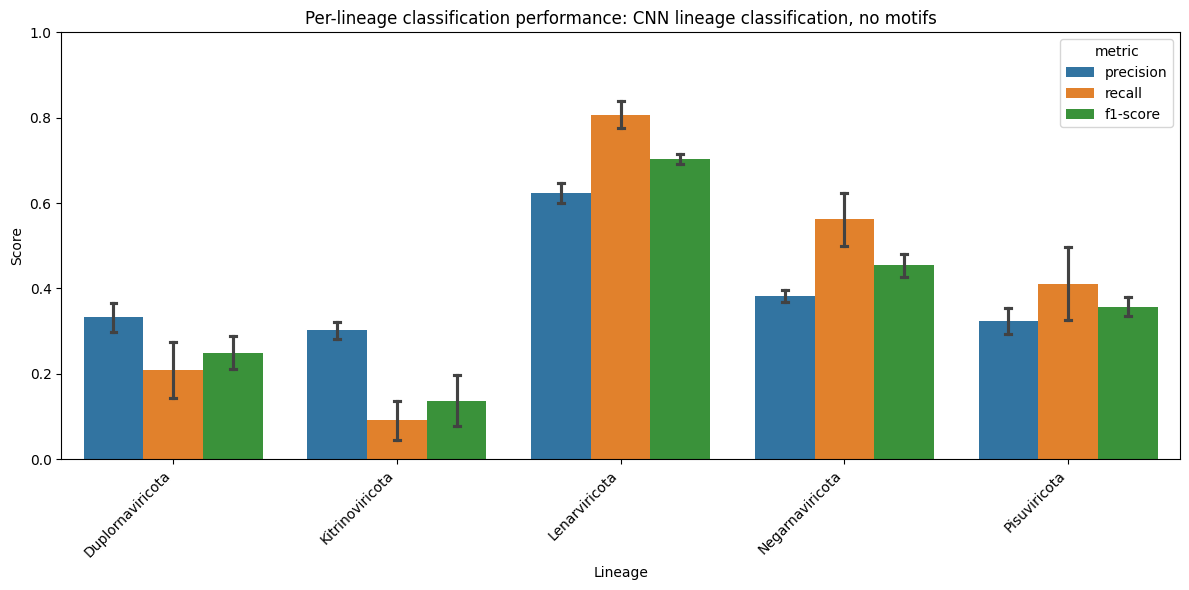

In [20]:
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=cnn_only_long,
    x="lineage",
    y="score",
    hue="metric",
    order=lineage_order,
    errorbar="sd",
    capsize=0.08
)

plt.ylim(0, 1)
plt.xlabel("Lineage")
plt.ylabel("Score")

plt.title(
    "Per-lineage classification performance: "
    "CNN lineage classification, no motifs"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.legend(
    title="metric"
)

plt.tight_layout()

plt.savefig(
    "cnn_only_per_lineage_performance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

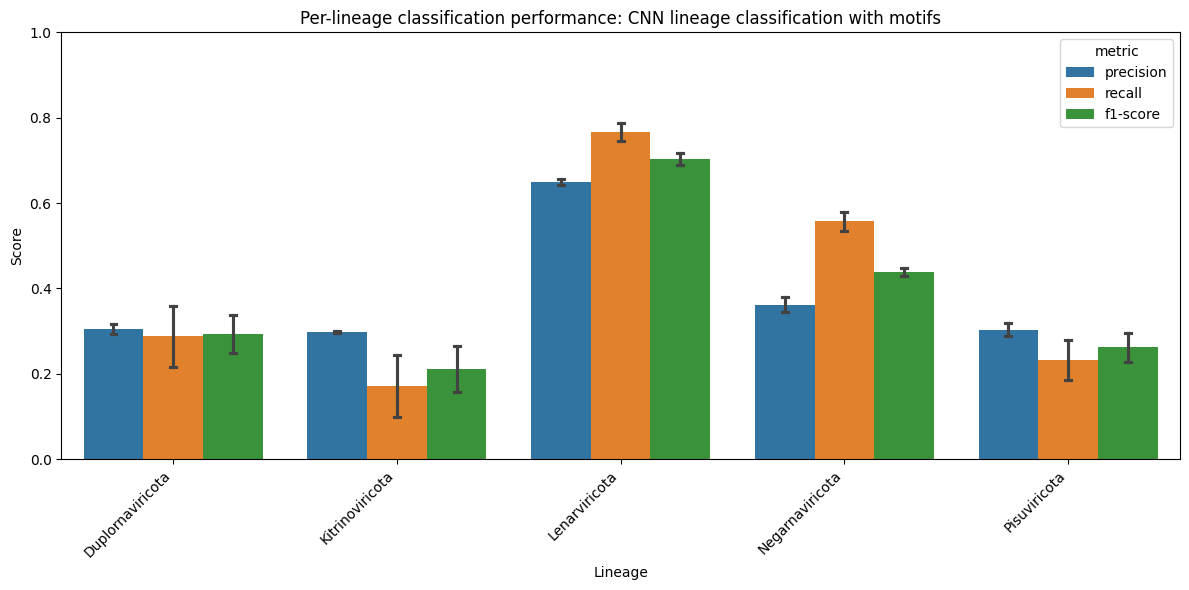

In [21]:
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=cnn_motif_long,
    x="lineage",
    y="score",
    hue="metric",
    order=lineage_order,
    errorbar="sd",
    capsize=0.08
)

plt.ylim(0, 1)
plt.xlabel("Lineage")
plt.ylabel("Score")

plt.title(
    "Per-lineage classification performance: "
    "CNN lineage classification with motifs"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.legend(
    title="metric"
)

plt.tight_layout()

plt.savefig(
    "cnn_motif_per_lineage_performance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

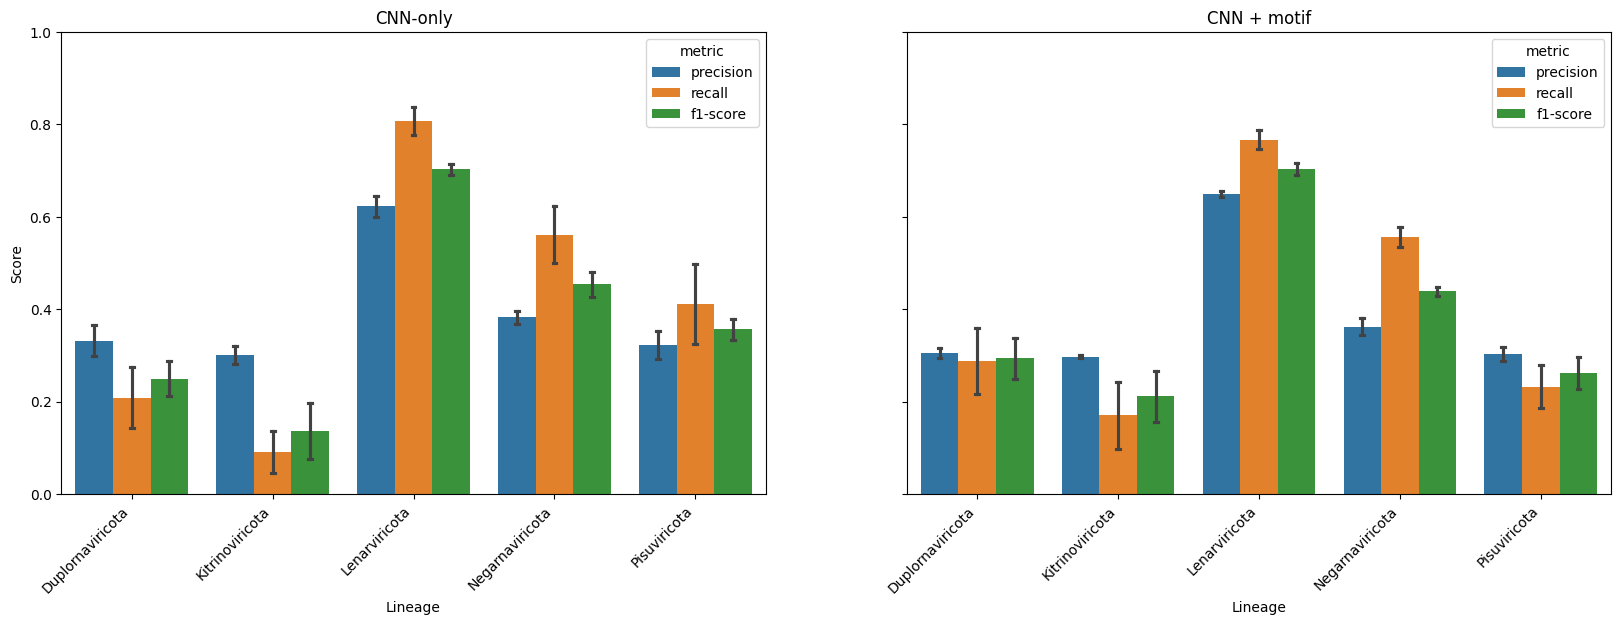

In [22]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(20, 6),
    sharey=True
)

sns.barplot(
    data=cnn_only_long,
    x="lineage",
    y="score",
    hue="metric",
    order=lineage_order,
    errorbar="sd",
    capsize=0.08,
    ax=axes[0]
)

axes[0].set_title(
    "CNN-only"
)

axes[0].set_xlabel("Lineage")
axes[0].set_ylabel("Score")
axes[0].set_ylim(0, 1)
axes[0].tick_params(
    axis="x",
    rotation=45
)

for label in axes[0].get_xticklabels():
    label.set_horizontalalignment("right")


sns.barplot(
    data=cnn_motif_long,
    x="lineage",
    y="score",
    hue="metric",
    order=lineage_order,
    errorbar="sd",
    capsize=0.08,
    ax=axes[1]
)

axes[1].set_title(
    "CNN + motif"
)

axes[1].set_xlabel("Lineage")
axes[1].set_ylabel("")
axes[1].set_ylim(0, 1)
axes[1].tick_params(
    axis="x",
    rotation=45
)

for label in axes[1].get_xticklabels():
    label.set_horizontalalignment("right")

In [9]:
cnn_only_lineage_counts = create_lineage_counts(
    predictions_df=cnn_only_predictions,
    model_name="CNN-only",
    lineage_order=lineage_order
)

cnn_motif_lineage_counts = create_lineage_counts(
    predictions_df=cnn_motif_predictions,
    model_name="CNN + motif",
    lineage_order=lineage_order
)

lineage_counts = pd.concat(
    [
        cnn_only_lineage_counts,
        cnn_motif_lineage_counts
    ],
    ignore_index=True
)

display(lineage_counts)

,model,seed,lineage,type,count
0,CNN-only,0,Duplornaviricota,True,498
1,CNN-only,0,Duplornaviricota,Predicted,214
2,CNN-only,0,Kitrinoviricota,True,498
3,CNN-only,0,Kitrinoviricota,Predicted,188
4,CNN-only,0,Lenarviricota,True,498
5,CNN-only,0,Lenarviricota,Predicted,615
6,CNN-only,0,Negarnaviricota,True,499
7,CNN-only,0,Negarnaviricota,Predicted,811
8,CNN-only,0,Pisuviricota,True,499
9,CNN-only,0,Pisuviricota,Predicted,664


In [11]:
true_count_check = (
    lineage_counts[
        lineage_counts["type"] == "True"
    ]
    .groupby(
        ["model", "seed", "lineage"]
    )["count"]
    .sum()
    .unstack("model")
)

display(true_count_check)

model                  CNN + motif  CNN-only
seed lineage                                
0    Duplornaviricota          498       498
     Kitrinoviricota           498       498
     Lenarviricota             498       498
     Negarnaviricota           499       499
     Pisuviricota              499       499
1    Duplornaviricota          499       499
     Kitrinoviricota           498       498
     Lenarviricota             498       498
     Negarnaviricota           499       499
     Pisuviricota              498       498
2    Duplornaviricota          499       499
     Kitrinoviricota           498       498
     Lenarviricota             498       498
     Negarnaviricota           499       499
     Pisuviricota              498       498

In [23]:
lineage_counts["group"] = (
    lineage_counts["model"]
    + " — "
    + lineage_counts["type"]
)

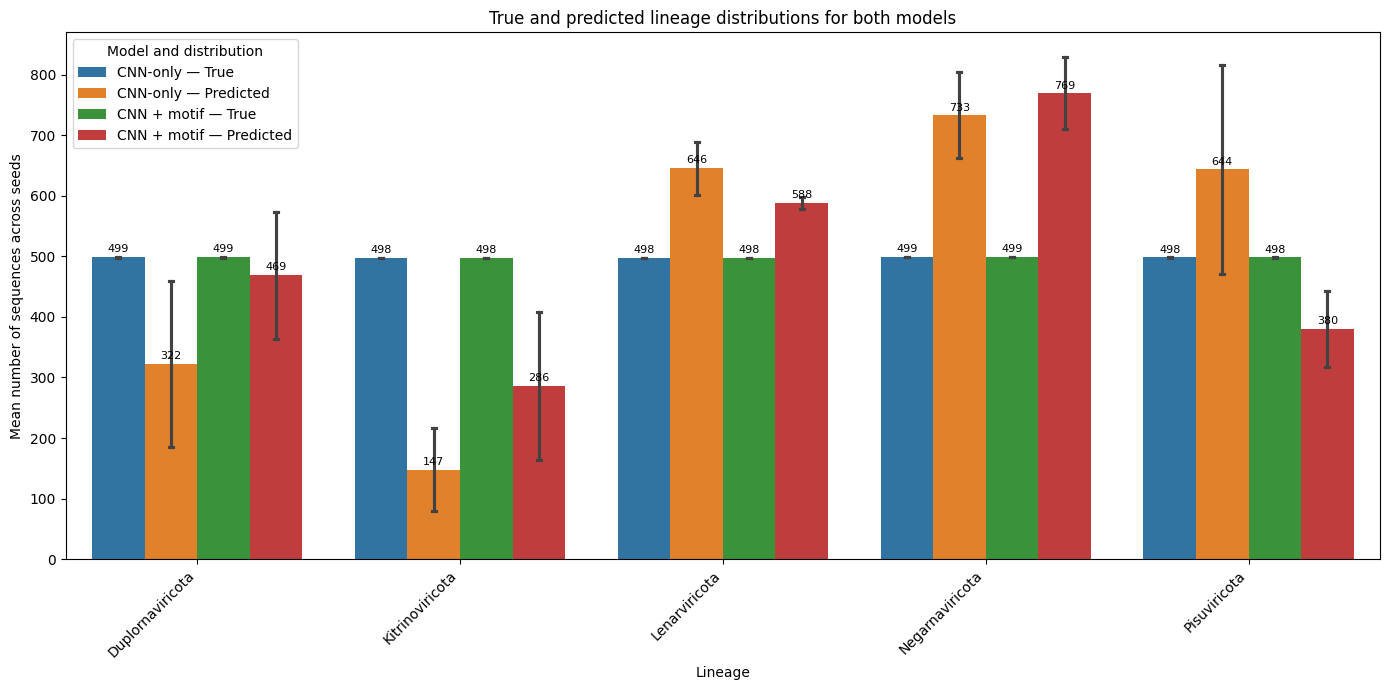

In [24]:
plt.figure(figsize=(14, 7))

ax = sns.barplot(
    data=lineage_counts,
    x="lineage",
    y="count",
    hue="group",
    order=lineage_order,
    hue_order=[
        "CNN-only — True",
        "CNN-only — Predicted",
        "CNN + motif — True",
        "CNN + motif — Predicted"
    ],
    errorbar="sd",
    capsize=0.06
)

plt.xlabel("Lineage")
plt.ylabel("Mean number of sequences across seeds")
plt.title("True and predicted lineage distributions for both models")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.legend(
    title="Model and distribution"
)

plt.tight_layout()

plt.savefig(
    "true_vs_predicted_lineages_both_models_grouped.png",
    dpi=300,
    bbox_inches="tight"
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f",
        padding=2,
        fontsize=8
    )

plt.show()

In [14]:
cnn_only_accuracy = calculate_accuracy_by_seed(
    cnn_only_predictions,
    "CNN-only"
)

cnn_motif_accuracy = calculate_accuracy_by_seed(
    cnn_motif_predictions,
    "CNN + motif"
)

accuracy_comparison = pd.concat(
    [
        cnn_only_accuracy,
        cnn_motif_accuracy
    ],
    ignore_index=True
)

display(accuracy_comparison)

,model,seed,accuracy
0,CNN-only,0,0.418138
1,CNN-only,1,0.413323
2,CNN-only,2,0.416533
3,CNN + motif,0,0.406100
4,CNN + motif,1,0.398475
5,CNN + motif,2,0.404494


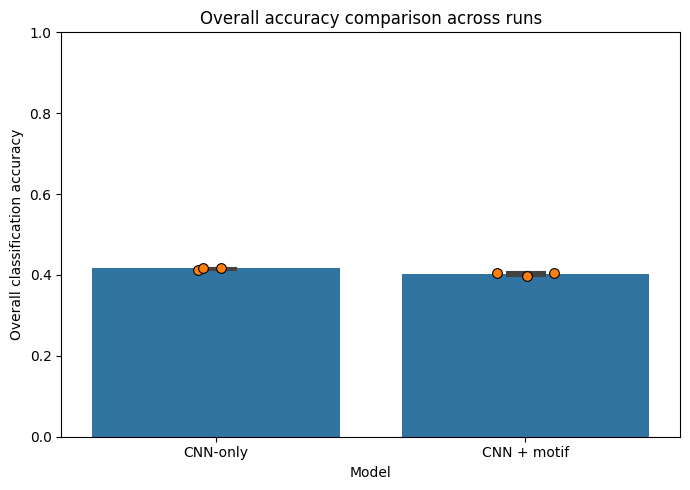

In [15]:
plt.figure(figsize=(7, 5))

ax = sns.barplot(
    data=accuracy_comparison,
    x="model",
    y="accuracy",
    errorbar="sd",
    capsize=0.12
)

sns.stripplot(
    data=accuracy_comparison,
    x="model",
    y="accuracy",
    size=7,
    linewidth=0.8,
    edgecolor="black"
)

plt.ylim(0, 1)
plt.xlabel("Model")
plt.ylabel("Overall classification accuracy")
plt.title("Overall accuracy comparison across runs")

plt.tight_layout()

plt.savefig(
    "cnn_models_accuracy_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [16]:
accuracy_summary = (
    accuracy_comparison
    .groupby("model")["accuracy"]
    .agg(
        mean="mean",
        std="std"
    )
    .reset_index()
)

accuracy_summary["mean_sd"] = (
    accuracy_summary["mean"].map(
        lambda value: f"{value:.3f}"
    )
    + " ± "
    + accuracy_summary["std"].map(
        lambda value: f"{value:.3f}"
    )
)

display(accuracy_summary)

,model,mean,std,mean_sd
0,CNN + motif,0.403023,0.004020,0.403 ± 0.004
1,CNN-only,0.415998,0.002452,0.416 ± 0.002
